# Soft and Hard Ensemble Voting Classifiers (DT and kNN).

**Learning Outcomes:**
1. Implement ensembles models using soft and hard voting approaches
2. Realise the effect of the ensemble on the classifier decision boundaries
In this exercise, we show to implement a voting techniques in order to combine several models classifications in one powerful model. We train everything on a simple dataset to demonstrate the principles.

Disclaimer: The code is adopted from sklearn tutorial on plot_voting_decision_regions code


In [1]:
%matplotlib inline

In [2]:
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier

#from helpers import plotClassBoundary # uncomment to use this function it should be in the same directory of the sheet

## Loading some Gaussian example data with noise

In [3]:
data = pd.read_csv('datasets/GaussNoiseC1C2_10perc.csv').to_numpy()
X = data[:, [0,1]]
X1 = X[:,0]
X2 = X[:,1]
y = data[:, 2]

## Training classifiers
Note that DecisionTreeClassifier uses CART by default, currently there is no parameter to changed 
it to another algorithm. The default criterion = 'gini' but this can be changed to 'entropy' we 
can choose splitter = 'best'.

The following classifiers have been roughly optimised via trial and error and by knowing the nature of the data. 
Try to optimise by tuning hyper parameters via grid search

In [4]:
clf1 = DecisionTreeClassifier(max_depth=4,min_samples_split=235,min_samples_leaf=20) # min_weight_fraction_leaf=0.1)
#clf1 = DecisionTreeClassifier() # uncomment try this to see overfitting!
clf2 = KNeighborsClassifier(n_neighbors=7)

clfHard = VotingClassifier(estimators=[('dt', clf1), ('knn', clf2)], voting='hard', weights=[2, 1])
clfSoft = VotingClassifier(estimators=[('dt', clf1), ('knn', clf2)], voting='soft', weights=[2, 1])

# note that you could directly fit the voting models without fitting the individual classifiers separately
# we fit all of them to compare thier performances
clf1.fit(X, y)
clf2.fit(X, y)
clfHard.fit(X, y)
clfSoft.fit(X, y)
pass # to prevent printing

## Plotting decision boundaries of the 4 classifiers

NameError: name 'Y' is not defined

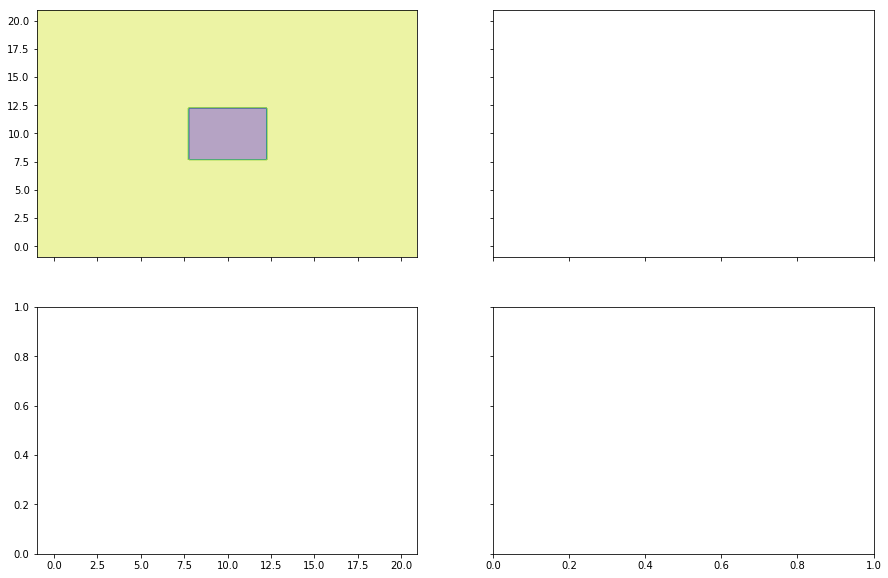

In [5]:
# uncomment to plto the DT
# plt.figure(figsize=(10,6))
# Ptree = plot_tree(clf1, filled=True, fontsize=8)#, rounded=True, label='none', impurity = True, feature_names=['x1', 'x2'], class_names= ['C1', 'C2'])

# Plotting decision regions
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

f, axarr = plt.subplots(2, 2, sharex='col', sharey='row', figsize=(15, 10))
titles = ['Decision Tree (depth='+str(clf1.tree_.max_depth)+')', 
                         'kNN (k='+str(clf2.n_neighbors)+')',
                         clfHard.voting + ' voting [DT, kNN, Percep] weights '+ str(clfHard.weights),
                         clfSoft.voting + ' voting [DT, kNN, MLP] weights '   + str(clfSoft.weights)]

for idx, clf, tt in zip(product([0, 1], [0, 1]),
                        [clf1, clf2, clfHard, clfSoft ],
                        titles):
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    axarr[idx[0], idx[1]].contourf(xx, yy, Z, alpha=0.4)
    axarr[idx[0], idx[1]].scatter(X[:, 0], X[:, 1], c=Y, s=10, edgecolor='w', facecolor='w')
    axarr[idx[0], idx[1]].set_title(tt)

plt.show()

Try to use our helper function to plot the boundaries 
plotClassBoundary

### Your Turn

Now it is your turn apply the employ the same on the titanic dataset to reap the benefit of soft and hard voting.
Imagine, that you have travelled through time with your laptop to the time of before the Titanic is sailing. You have been asked to vet the passenger in case the ship is drowned based on your own prediction whether a passenger is likely to survive or not. Your task is to build a prediction model that will predict if a passenger is likely to survive a ship sink. You are equipped with the titanic dataset and you have decided to build a predictive model to aid you in your decision. The traveling company wants to stay on the safe side by only boarding passengers that are likely to survive even if it meant that they might reject some passengers by mistake.
You would need to 
1. pre-process the dataset as we did in earlier units and then apply both kNN and DT on it.
2. Make sure to split the data first into training and testing, and
3. apply cross validation on the *training set* in order to tune the hyper parameters reliably.
4. Then report the performance of the 4 algorithms on the testing dataset.
5. Use 4 types of scores F1, Accuracy, Precision and Recall (remember we call the precision and recall predict and detect, respectively)
6. Give a final recommendation on which model to use given that we want to stay on the safe side.
7. When picking a model out of the 4, use a suitable performance metric for your decisions to reject or accept a person based on the company needs. Discuss this task on the group if you want.


1. pre-process the dataset as we did in earlier units and then apply both kNN and DT on it. 

2. Make sure to split the data first into training and testing, and 


3. apply cross validation on the *training set* in order to tune the hyper parameters reliably. 


4. Then report the performance of the 4 algorithms on the testing dataset. 


5. Use 4 types of scores F1, Accuracy, Precision and Recall (remember we call the precision and recall, predict and detect, respectively)


6. Give a final recommendation on which model to use given that we want to stay on the safe side.


7. When picking a model out of the 4, use a suitable performance metric for your decisions to reject or accept a person based on the company needs. Discuss this task on the group if you want. 
